In [1]:
import pandas as pd  
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../Data/final/environment_data.csv")

In [3]:
def detect_outliers_iqr(df, city=None):
    if city is not None:
        df = df[df["City"] == city]
    
    outlier_summary = []
    outlier_rows = pd.DataFrame()

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col == "isWeekend" or col=="Electricity Consumption":
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers["Outlier_Feature"] = col   
        outlier_rows = pd.concat([outlier_rows, outliers])
        
        outlier_summary.append({
            "Feature": col,
            "Outliers_Count": len(outliers),
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2)
        })
    
    return pd.DataFrame(outlier_summary), outlier_rows



In [4]:
summary, outlier_rows = detect_outliers_iqr(df, city="Paris")
print(summary.sort_values(by="Outliers_Count", ascending=False))

             Feature  Outliers_Count  Lower_Bound  Upper_Bound
4                 CO              26        68.79       319.79
5                SO2              24        -0.56         5.24
11          Pressure              19       986.55      1027.35
0              PM2.5              17        -4.09        23.01
1               PM10              14        -2.02        32.16
3                NO2              10        -7.39        48.88
2                 O3               2        -0.69       101.15
10        Wind_speed               2         0.40        22.56
9           Humidity               1        37.98       106.81
6        Green_Space               0       164.00       164.00
7   Temperature_mean               0        -6.29        34.71
8    Temperature_max               0        -6.00        42.00


C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_14480\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_14480\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_14480\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

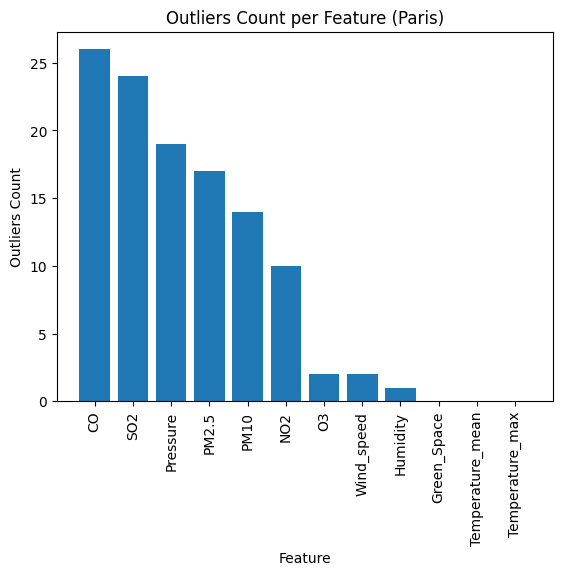

In [5]:
summary_sorted = summary.sort_values(by="Outliers_Count", ascending=False)
plt.figure()
plt.bar(summary_sorted["Feature"], summary_sorted["Outliers_Count"])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Outliers Count")
plt.title("Outliers Count per Feature (Paris)")
plt.show()

In Paris, outliers were mainly concentrated in air pollution indicators such as CO and SO2, while climate-related features showed very few abnormal observations.

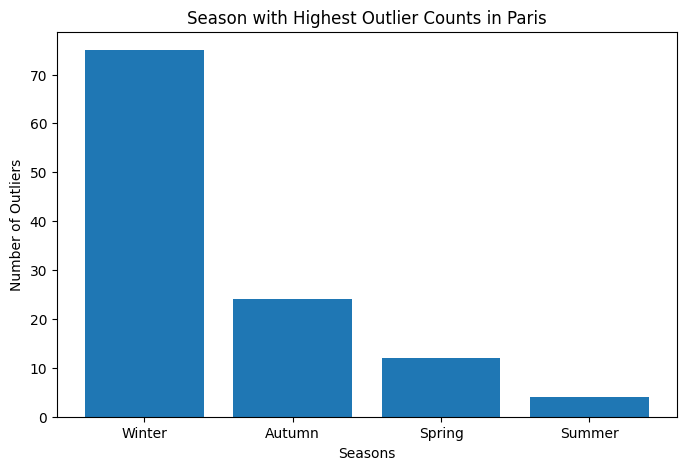

In [6]:
season_outliers = outlier_rows["Season"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(season_outliers.index.astype(str), season_outliers.values)

plt.xlabel("Seasons")
plt.ylabel("Number of Outliers")
plt.title("Season with Highest Outlier Counts in Paris")

plt.show()

Winter recorded the highest number of outliers in Paris by a large margin, indicating greater variability in environmental and pollution-related conditions during colder months. In contrast, Summer showed the fewest outliers, suggesting more stable conditions.

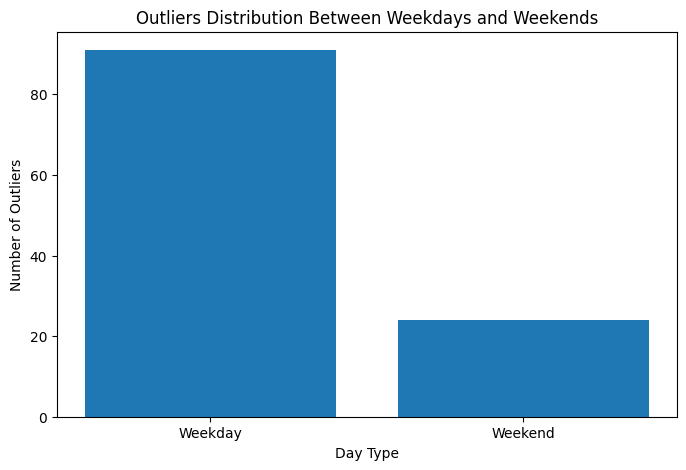

In [7]:
plt.figure(figsize=(8,5))
z=outlier_rows["isWeekend"].value_counts()
plt.bar(z.index.astype(str), z.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Outliers")
plt.title("Outliers Distribution Between Weekdays and Weekends")

plt.xticks([0,1], ["Weekday", "Weekend"])

plt.show()

Severe pollution events in Nairobi appear to be more strongly associated with regular working days and daily human activities rather than weekends or holiday periods.

In [8]:
normal_rows = df[~df.index.isin(outlier_rows.index)]

outliers_mean = outlier_rows.mean(numeric_only=True)
normal_mean = normal_rows.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Outliers": outliers_mean,
    "Normal": normal_mean
})

comparison

,Outliers,Normal
PM2.5,2.455917e+01,2.046950e+01
PM10,3.300667e+01,3.731568e+01
O3,2.333007e+01,5.503943e+01
NO2,4.520714e+01,3.306117e+01
CO,3.535790e+02,3.394156e+02
SO2,6.631884e+00,1.467312e+01
Green_Space,1.640000e+02,1.038170e+02
Temperature_mean,8.296660e+00,1.924418e+01
Temperature_max,1.247826e+01,2.347793e+01
Humidity,7.523803e+01,6.437975e+01


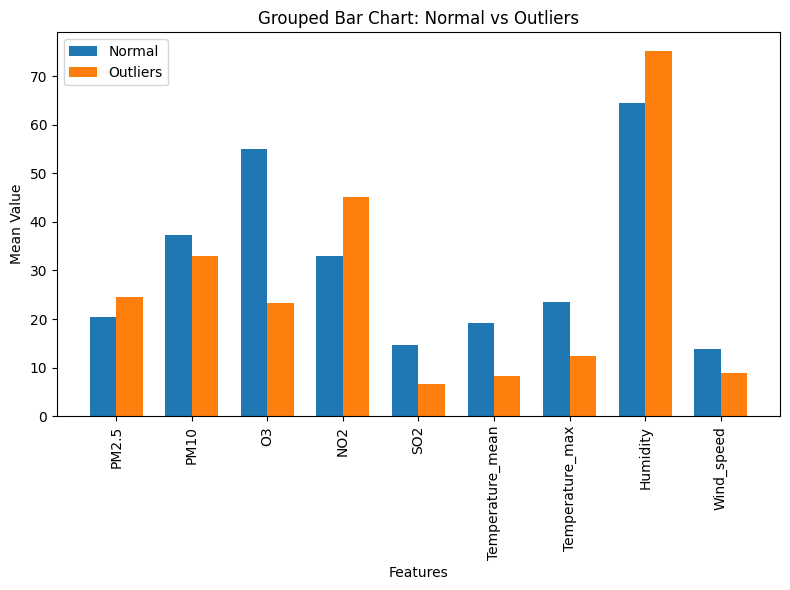

In [9]:

compare = comparison.drop(["Pressure", "isWeekend","CO","Electricity Consumption","Green_Space"])
features = compare.index

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    compare["Normal"],
    width=width,
    label="Normal"
)

plt.bar(
    x + width/2,
    compare["Outliers"],
    width=width,
    label="Outliers"
)

plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")

plt.legend()

plt.tight_layout()

plt.show()

Outlier observations in Paris were associated with higher humidity, NO2, and PM2.5 levels, while most other environmental variables showed lower values compared to normal conditions.

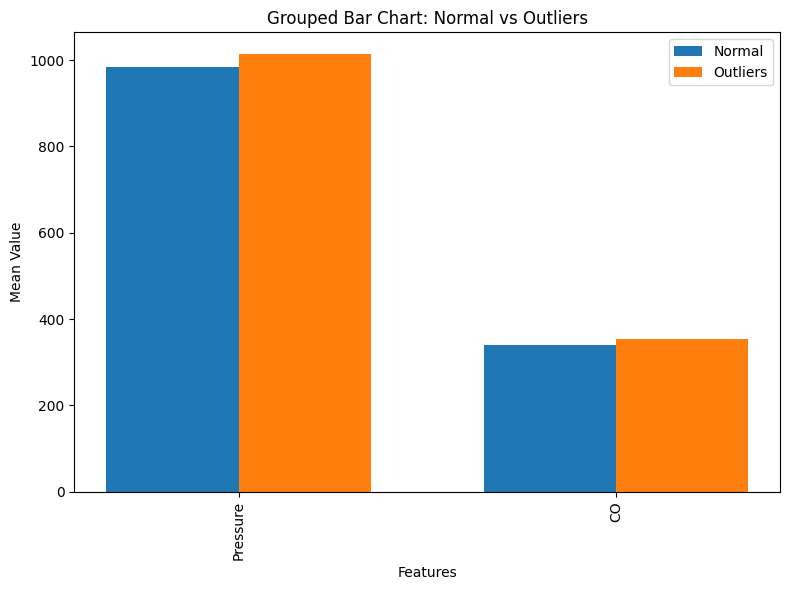

In [10]:
others= comparison.loc[["Pressure","CO"],:]
plt.figure(figsize=(8,6))
features=others.index
x=np.arange(len(features))
width=0.35
plt.bar(
    x-width/2,
    others["Normal"],
    width=width,
    label="Normal"
)
plt.bar(
    x+width/2,
    others["Outliers"],
    width=width,
    label="Outliers"
)
plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")
plt.legend()
plt.tight_layout()
plt.show()

Pressure and CO values during outlier events were very close to normal observations, suggesting that these features were not significantly affected during abnormal conditions.
